Question 1 : Intensity Transformations on the Runway Image

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [4]:
#Load Image
img_path = 'images/runway.png'
img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

#Normalize image to [0,1]
img_norm = img / 255.0

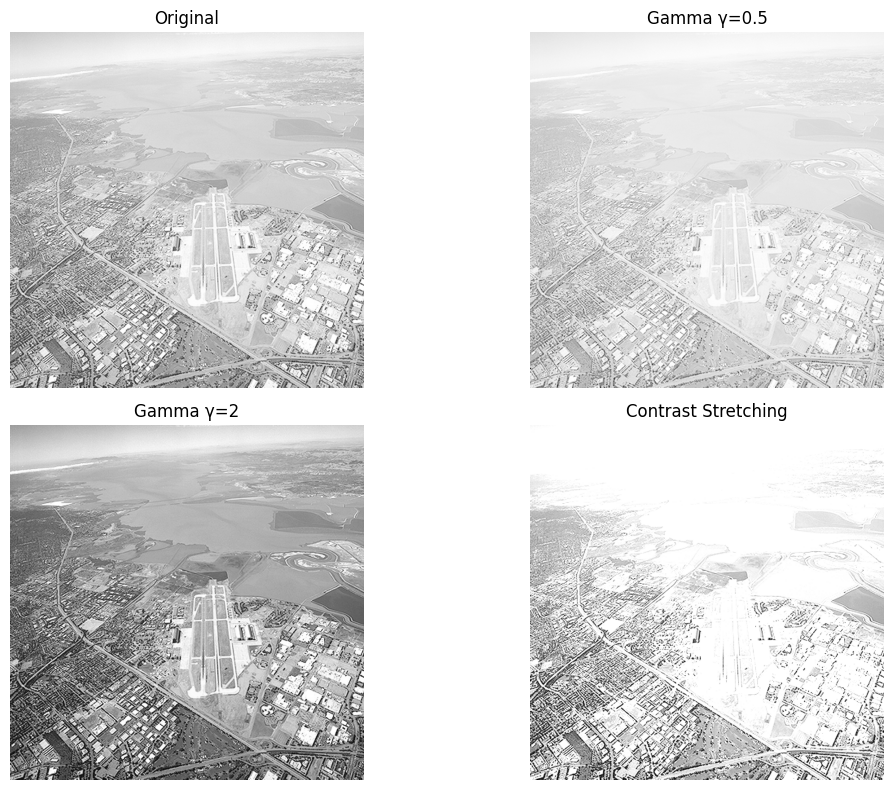

In [5]:
# a) Gamma correction (γ = 0.5)
gamma_05 = np.power(img_norm, 0.5)

# b) Gamma correction (γ = 2)
gamma_2 = np.power(img_norm, 2)

# c) Contrast Stretching (Piecewise function)
r1, r2 = 0.2, 0.8

contrast = np.zeros_like(img_norm)

# Apply piecewise transformation
contrast[img_norm < r1] = 0
mask = (img_norm >= r1) & (img_norm <= r2)
contrast[mask] = (img_norm[mask] - r1) / (r2 - r1)
contrast[img_norm > r2] = 1

# Convert back to [0,255] for display
gamma_05_img = (gamma_05 * 255).astype(np.uint8)
gamma_2_img = (gamma_2 * 255).astype(np.uint8)
contrast_img = (contrast * 255).astype(np.uint8)

# Display results
titles = ["Original", "Gamma γ=0.5", "Gamma γ=2", "Contrast Stretching"]
images = [img, gamma_05_img, gamma_2_img, contrast_img]

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Question 2 : Gamma Correction in Lab* Color Space

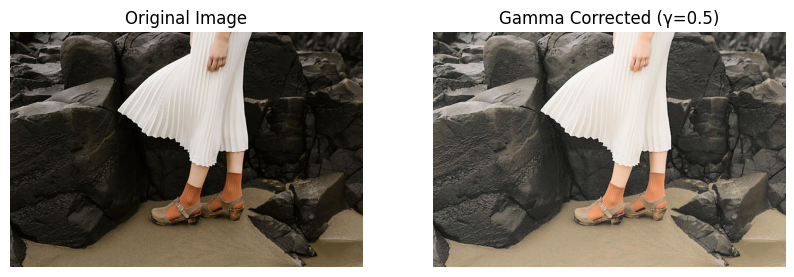

In [6]:
# Load image (BGR)
img_path = "images/highlights_and_shadows.jpg"
img_bgr = cv.imread(img_path)

# Convert to RGB for display
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Convert to LAB color space
lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

# Split channels
L, a, b = cv.split(lab)

# Normalize L channel to [0,1]
L_norm = L / 255.0

# -------- Gamma Correction --------
gamma = 0.5   # ✅ chosen gamma value
L_corrected = np.power(L_norm, gamma)

# Scale back to [0,255]
L_corrected = (L_corrected * 255).astype(np.uint8)

# Merge channels back
lab_corrected = cv.merge((L_corrected, a, b))

# Convert back to RGB
img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2RGB)

# Display results
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_corrected)
plt.title(f"Gamma Corrected (γ={gamma})")
plt.axis('off')

plt.show()

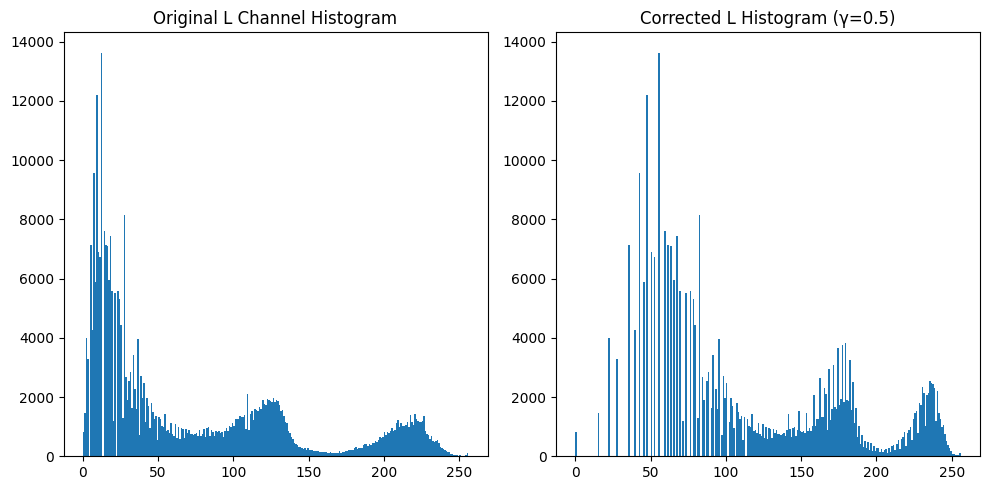

In [7]:
# Histogram of original and corrected L channel

plt.figure(figsize=(10,5))

# Original histogram
plt.subplot(1,2,1)
plt.hist(L.flatten(), bins=256, range=[0,256])
plt.title("Original L Channel Histogram")

# Corrected histogram
plt.subplot(1,2,2)
plt.hist(L_corrected.flatten(), bins=256, range=[0,256])
plt.title(f"Corrected L Histogram (γ={gamma})")

plt.tight_layout()
plt.show()

Question 3 : Custom Histogram Equalization on Runway Image

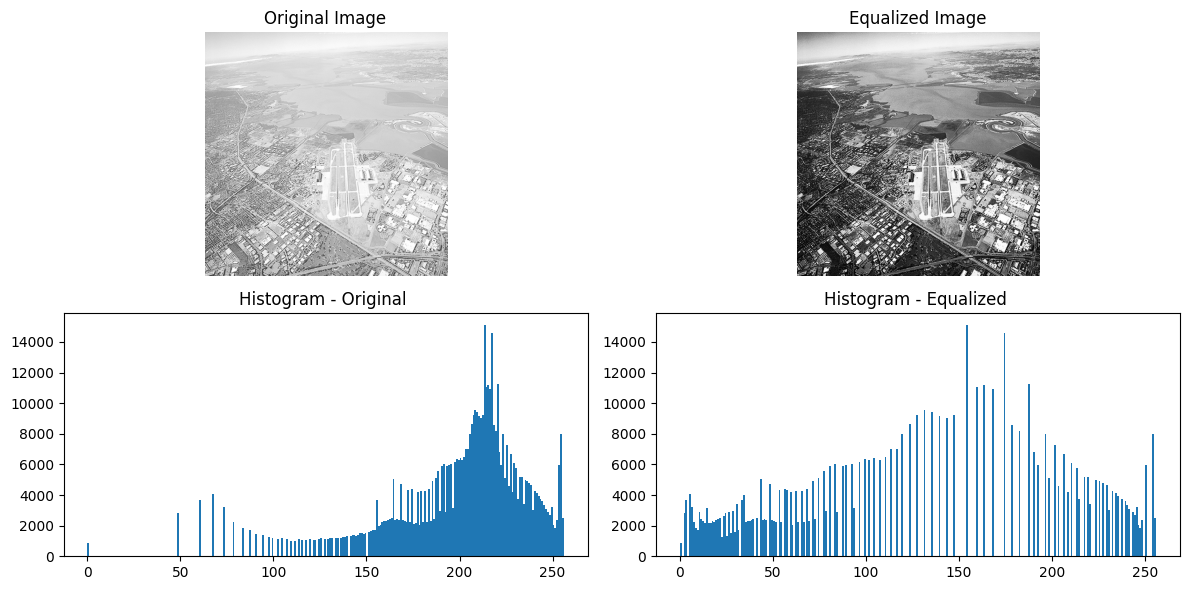

In [10]:
def histogram_equalization(image):
    # Flatten image
    flat = image.flatten()

    #Compute histogram (256 bins for 8-bit image)
    hist = np.zeros(256, dtype=int)
    for pixel in flat:
        hist[pixel] += 1

    #Normalize histogram (PDF)
    total_pixels = flat.size
    pdf = hist / total_pixels

    #Compute CDF
    cdf = np.cumsum(pdf)

    #Create mapping (scale to [0,255])
    cdf_normalized = np.round(cdf * 255).astype(np.uint8)

    #Map original pixels using CDF
    equalized_flat = cdf_normalized[flat]

    #Reshape back to original image
    equalized_img = equalized_flat.reshape(image.shape)

    return equalized_img, hist, cdf

# Apply histogram equalization
equalized_img, hist, cdf = histogram_equalization(img)

# Display results
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Equalized Image
plt.subplot(2, 2, 2)
plt.imshow(equalized_img, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')

# Original Histogram
plt.subplot(2, 2, 3)
plt.hist(img.flatten(), bins=256, range=[0,256])
plt.title("Histogram - Original ")

# Equalized Histogram
plt.subplot(2, 2, 4)
plt.hist(equalized_img.flatten(), bins=256, range=[0,256])
plt.title("Histogram - Equalized ")

plt.tight_layout()
plt.show()

Question 4 : Otsu Thresholding and Selective Histogram Equalization

Otsu Threshold Value: 101.0


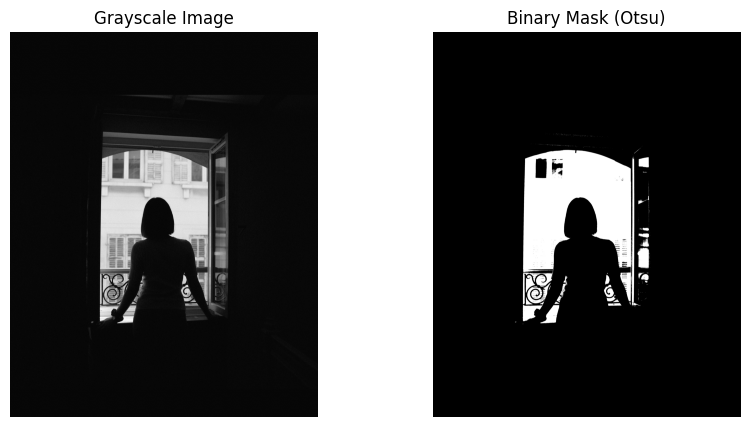

In [11]:
# Load image
img_path = "images/fig_3.jpg"
img = cv.imread(img_path)

# Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply Otsu thresholding
threshold_value, binary_mask = cv.threshold(
    gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
)

print("Otsu Threshold Value:", threshold_value)

# Display results
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask (Otsu)")
plt.axis('off')

plt.show()

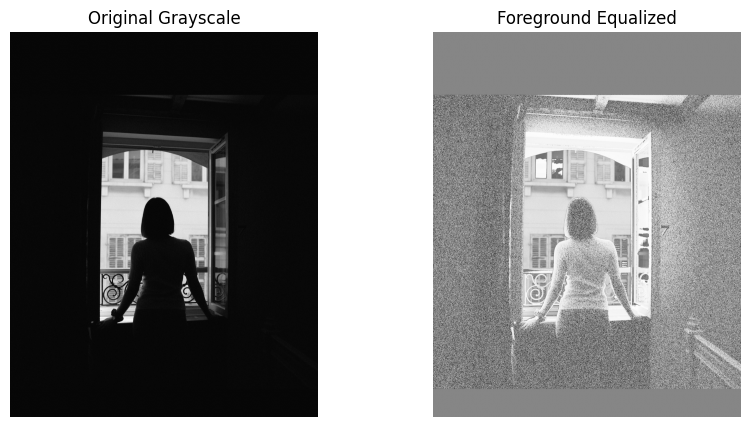

In [13]:
# Create a copy of grayscale image
equalized = gray.copy()

# Extract foreground pixels using mask
foreground_pixels = gray[binary_mask == 0]

# Perform histogram equalization ONLY on foreground
hist, bins = np.histogram(foreground_pixels, bins=256, range=[0,256])

# Compute CDF
cdf = hist.cumsum()
cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
cdf_normalized = cdf_normalized.astype(np.uint8)

# Map only foreground pixels
equalized[binary_mask == 0] = cdf_normalized[foreground_pixels]

# Display results
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray')
plt.title("Foreground Equalized")
plt.axis('off')

plt.show()

Question 5 : Gaussian Filtering

5x5 Gaussian Kernel (σ=2):
 [[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]
Sum = 0.9999999999999998


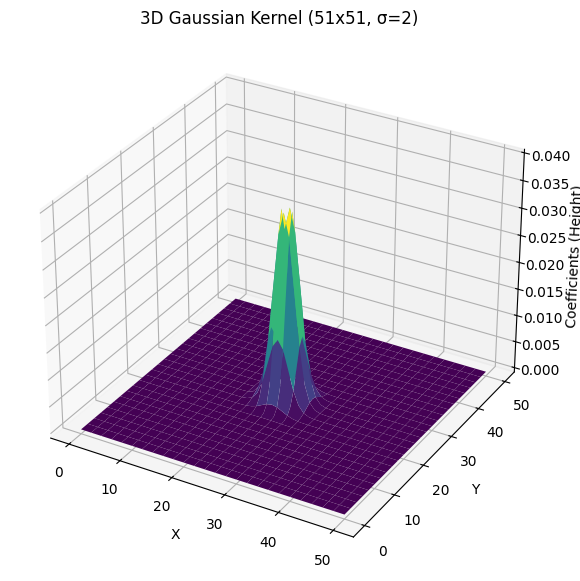

In [19]:
#a) Compute a normalized Gaussian
def gaussian_kernel(size, sigma):
    
    k = size // 2
    # Create centered coordinates from -k to k
    x, y = np.meshgrid(np.arange(-k, k+1), np.arange(-k, k+1))
    
    # Calculate the Gaussian distribution
    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    # Normalize the kernel so the weights sum to 1
    return kernel / np.sum(kernel)

# Compute 5x5 kernel for sigma=2 
kernel_5x5 = gaussian_kernel(5, 2)
print("5x5 Gaussian Kernel (σ=2):\n", kernel_5x5)
print("Sum =", np.sum(kernel_5x5))

#b) Visualize a 51x51 as a 3D surface plot
kernel_51 = gaussian_kernel(51, 2)

# Generate grid for the 51x51
x_grid = np.arange(51)
y_grid = np.arange(51)
X, Y = np.meshgrid(x_grid, y_grid)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, kernel_51, cmap='viridis')

ax.set_title("3D Gaussian Kernel (51x51, σ=2)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Coefficients (Height)")
plt.show()


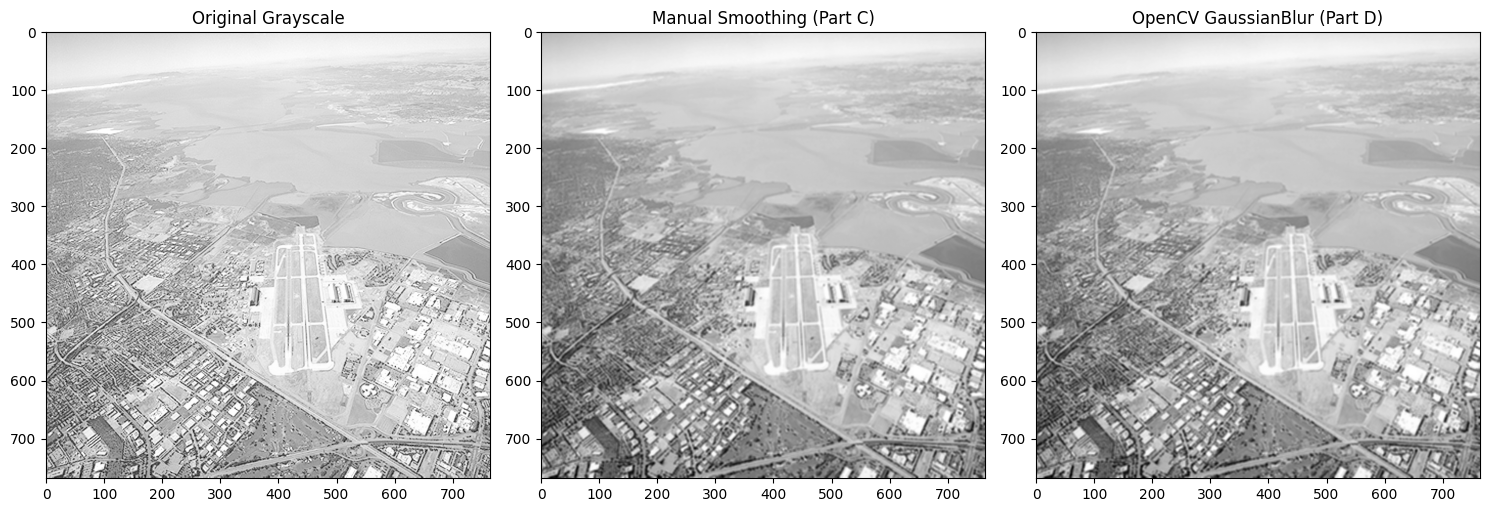

In [18]:
img = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found. Please provide a valid path.")
else:
    #c) Apply manual Gaussian smoothing
    img_manual = cv.filter2D(img, -1, kernel_5x5)

    #d) Apply smoothing using OpenCV's built-in function
    img_opencv = cv.GaussianBlur(img, (5, 5), sigmaX=2)

    # Visualize the results
    plt.figure(figsize=(15, 5))
    
    plt.subplot(131)
    plt.title("Original Grayscale")
    plt.imshow(img, cmap='gray')
    
    plt.subplot(132)
    plt.title("Manual Smoothing (Part C)")
    plt.imshow(img_manual, cmap='gray')
    
    plt.subplot(133)
    plt.title("OpenCV GaussianBlur (Part D)")
    plt.imshow(img_opencv, cmap='gray')
    
    plt.tight_layout()
    plt.show()